# Waveguide Grating Antenna

I am excited to recently explore one of the emerging applications in Photonics Integrated Circuits (PICs), i.e. Optical Phase Arrays (OPAs). The motivation stems from replacing conventional tip/tilt mirrors used for beam steering, especially for free space optical communications and laser material processings. OPAs are compact chips consisting of components like coupler, power splitter, modulators, grating antennas. In this tutorial, I discuss about the grating antennas which come at the end of the OPA circuit.

Among the different design types, I am focusing on 1D waveguide grating antennas with SOI platform. These are simpler in designs and computationally cheaper to simulate. Ofcourse, there are some limitations, so a trade off must always be considered depending on the applications. 

Here, I take a design as a reference from a paper, **Highly directional waveguide grating antenna for optical phased array** [https://doi.org/10.1016/j.cap.2018.04.004]

![structure](structure.PNG "Defined Structure")
Image Credit: [https://doi.org/10.1016/j.cap.2018.04.004]

The antenna is basically a waveguide core placed between the top and bottom cladding where the top clad is etched periodically to create gratings, while tthe bottom clad is a buried oxide layer that prevents the energy leakage to the substrate. This confines the mode highly in the core. The grating above are however, tiny pertubations that causes the light to leak upwards to radiate them in to free space. The leaked energy forms beam upward in space from the interference pattern created. 

I will show down here, how the far field pattern, as mentioned in the paper, is plotted. Due to computational limitation, I will be using the optimized parameters, as given in the paper. 

Let's set the simulation first by importing the lumapi package for lumerical scripting using Python.

In [1]:
import sys
sys.path.append(r'C:\Program Files\Lumerical\v241\api\python')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import lumapi
import math
import plotly.graph_objects as go 
import plotly.io as pio
%matplotlib inline

In [3]:
fdtd = lumapi.FDTD()

In [5]:
fde = lumapi.MODE()

The paramaters values are chosen from the paper mostly. 

In [6]:
# define wafer and waveguide structure
thick_Clad = 0.48e-6 # thickness of the top cladding layer
thick_Si = 0.12e-6 # thickness of the Si layer
thick_BOX = 2.0e-6 # thickness of the BOX layer
width_Si = 0.8e-6 # width of the waveguide
N = 10 # number of grating periods
l_g = 0.64e-6 # length of the grating period
dc = 0.6 # duty cycle of the grating
t_r = 0.08e-6 # thickness of the gap between the grating teeth and the core
t_g = thick_Clad - t_r # thickness of the grating teeth
l = N* l_g # total length of the waveguide
# define materials
material_Clad = "SiO2 (Glass) - Palik"
material_BOX = "SiO2 (Glass) - Palik"
material_Si = "Si (Silicon) - Palik"

# define simulation region
width_margin = 2.0e-6; # space to include on the side of the waveguide
height_margin = 1.0e-6; # space to include above and below the waveguide

# calculate simulation volume
# propagation in the x-axis direction; z-axis is wafer-normal
Xmin = -l/2-10e-6
Xmax = l/2+10e-6 # length of the waveguide
Zmin = -height_margin
Zmax = thick_Si + height_margin
Y_span = 2*width_margin + width_Si
Ymin = -Y_span/2
Ymax = -Ymin


Let's make a function to create the geometry. Reference taken from the book "Silicon..."

![Geometry](geometry.PNG "Geometry in Lumerical")


In [ ]:
def geometry(sim):
    sim.newproject()
    sim.addstructuregroup()
    sim.set("name", "geometry")

    # draw clad
    sim.addrect()
    sim.set("name", "clad")
    sim.addtogroup("geometry")
    sim.set("material", material_Clad)
    sim.set("y", 0)
    sim.set("y span", Y_span + 1e-6)
    sim.set("z min", 0)
    sim.set("z max", thick_Si + thick_Clad)
    sim.set("x min", Xmin)
    sim.set("x max", Xmax)
    sim.set("override mesh order from material database", 1)
    sim.set("mesh order", 2)  # similar to "send to back"
    sim.set("alpha", 0.5)

    # draw buried oxide
    sim.addrect()
    sim.set("name", "BOX")
    sim.addtogroup("geometry")
    sim.set("material", material_BOX)
    sim.set("x min", Xmin)
    sim.set("x max", Xmax)
    sim.set("y", 0)
    sim.set("y span", Y_span + 1e-6)
    sim.set("z min", -thick_BOX)
    sim.set("z max", 0)
    sim.set("alpha", 0.5)

    # draw silicon wafer
    sim.addrect()
    sim.set("name", "Wafer")
    sim.addtogroup("geometry")
    sim.set("material", material_Si)
    sim.set("x min", Xmin)
    sim.set("x max", Xmax)
    sim.set("z max", -thick_BOX)
    sim.set("z min", -thick_BOX - 2e-6)
    sim.set("y", 0)
    sim.set("y span", Y_span + 1e-6)
    sim.set("alpha", 0.4)

    # draw waveguide
    sim.addrect()
    sim.set("name", "waveguide")
    sim.addtogroup("geometry")
    sim.set("material", material_Si)
    sim.set("x min", Xmin)
    sim.set("x max", Xmax)
    sim.set("z min", 0)
    sim.set("z max", thick_Si)
    sim.set("y", 0)
    sim.set("y span", width_Si)

    # define grating
    xo = Xmin + 10e-6
    material_gap = "etch"
    xpos = xo
    for i in range(1, N):
        sim.addrect()
        sim.set("name", "grating_gap")
        sim.addtogroup("geometry")
        sim.set("material", material_gap)

        sim.set("x", xpos + 0.5 * l_g * (1 - dc))
        sim.set("x span", l_g * (1 - dc))

        sim.set("y", 0)
        sim.set("y span", Y_span + 1e-6)

        sim.set("z min", thick_Si + t_r)
        sim.set("z max", thick_Si + t_r + t_g)

        xpos = xpos + l_g
        


# MODE SOLVER

Before performing the FDTD simulation, it's important to first understand and visualize the waveguide modes.

In a rectangular waveguide, the structure excites either tranverse electric (TE) or transverse magnetic (TM) modes. 
In this application we are interested in TE modes. The propagation direction is in **X axis** and the cross section is in **yz** plane. Since the geometry varies in z direction, the electric field is present in **Y axis**, i.e. $E_{x}, E_{z} = 0$, $E_{y} \neq 0$.

Let's open the FDE solver to calculate the waveguide modes and analyse the influence of the two important paramaters: core width and thickness. 

First, calculate the modes in Lumerical using the function **findmodes()**. You can then visualize from **getresults()**. Here we focus on the electric field component. 

![Mode](mode_neff.PNG "Mode analysis")

Here you see, the $n_{eff}$ of our fundamental TE mode is 2.13 which is higher than the cladding (SiO2), so it is confined. You can visualize the modes in the Eigensolver Analysis Tab or clickk on individual modes on Object Library > FDE > mode1. 


To understand the influence of the width and thickness, you can perform the parameter sweep and calculate the neff. 
Here I swept the thickness of the waveguide core from 0.1 to 1 $\mu$ m for 10 points for the fundamental mode. This can be performed for other modes and widths too.  

In [95]:
def mode(sim):
    geometry(sim)
    sim.addfde()
    sim.set("solver type", 1)
    sim.set("z", 0)
    sim.set("z span", 4e-6)
    sim.set("x", 0)
    sim.set("y", thick_Si/2)
    sim.set("y span", 3e-6)
    sim.set("define y mesh by", 1)
    sim.set("define z mesh by", 1)
    sim.set("dy", 0.02e-6)
    sim.set("dz", 0.02e-6)
    sim.findmodes()


def mode_analysis(sim):
    mode(sim)
    E = sim.getresult("mode1", "E")
    return E

def paramater_setup(name, parameter, start, stop):
    # define the parameter thickness
    para = {
        "Name": name,
        "Parameter": f"::model::geometry::waveguide::{parameter}", 
        "Type": "Length",
        "Start": start,
        "Stop": stop,
        "Units": "microns"
    }
    return para

def result_setup(name, number):
    # define results
    result = {
        "Name": name,
        "Result": f"::model::FDE::data::mode{number}::neff", 
    }
    return result

def sweep_parameters(sim, paramater_name, para):
    # sim.newproject()
    # mode(fde)
    sim.addsweep(0)
    sim.setsweep("sweep", "name", paramater_name)
    sim.setsweep(paramater_name, "type", "Ranges")
    sim.setsweep(paramater_name, "number of points", 10)

    
    neff = []
    # define results
    for i in range(1, 5):
        neff.append(result_setup(f"neff{i}", i))
    sim.addsweepparameter(paramater_name, para)
    
    for i in range(1, 5):
        sim.addsweepresult(paramater_name, neff[i-1])

    sim.save(r"C:\Users\Reema\PIC\Tutorial\mode_sweep.lms")
    sim.runsweep(paramater_name)



# mode(fde)
# mode_analysis(fde)
para_t = paramater_setup(
        name="thickness",
        parameter="z span",  # adjust path if needed
        start=0.05e-6,
        stop=0.5e-6
    )
para_w = paramater_setup(
        name="width",
        parameter="y span",  # adjust path if needed
        start=0.3e-6,
        stop=1.3e-6
    )
# sweep_parameters(fde, "thickness_sweep", para_t)
sweep_parameters(fde, "width_sweep", para_w)


In [102]:
def sweep_analysis(sim, sweep_name, p, x_):
    for i in range(1, 5):
        neff = sim.getsweepresult(sweep_name, f'neff{i}')
        plt.plot(neff[p][0], neff['neff'], marker='o', label=f'neff{i}')

    plt.axhline(y=1.45, color='k', linestyle='--')
    plt.text(neff[p][0][0]+0.25e-6, 1.45 + 0.02, 'n_clad = 1.45', color='k')

    plt.axvline(x=x_, color='k', linestyle='-.')
    plt.text(x_ + 0.01e-6, plt.ylim()[1]*0.9, 'thick = 0.12 μm', rotation=90, color='k', va='bottom')

    plt.xlabel(p)
    plt.ylabel('Effective Index (neff)')
    plt.grid(True)
    plt.legend()

As you can see here, for the chosen  thickness  = 120 nm, the width that allows only fundamental TE mode should be around $\le$ 1000 nm, but something around 800 nm gives you both the fundamental modes. We say it's a safe number. 

The chosen thickness is to maximize the reflection in updward direction (refer to the paper for details). 

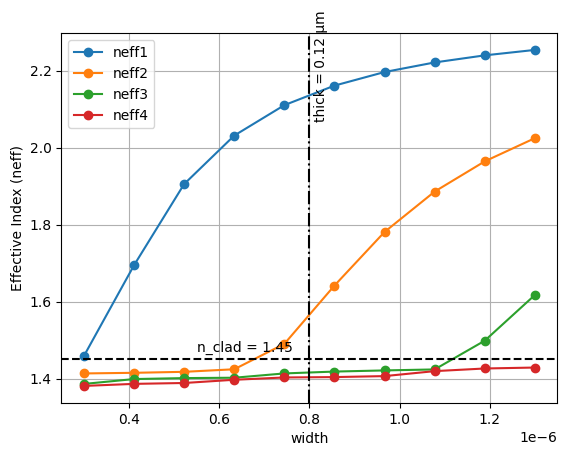

In [103]:
sweep_analysis(fde, "width_sweep", "width", 0.8e-6)

You can see for the chosen width = 800nm, the thickness sweep looks as below. Thickness greater than 120 nm might have impact from higher modes. 

c:\Users\Reema\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Reema\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


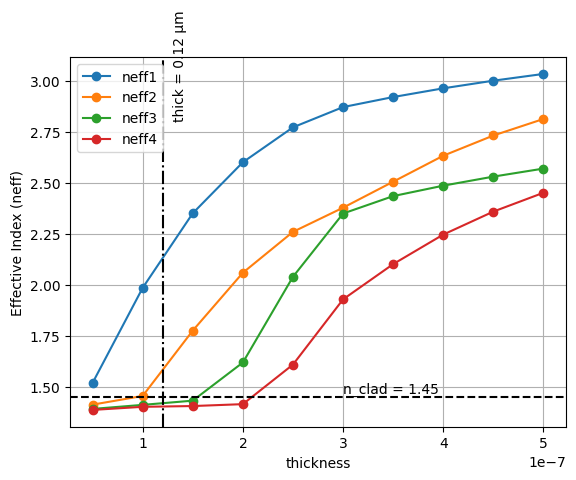

In [104]:
sweep_analysis(fde, "thickness_sweep", "thickness", 0.12e-6)

# FDTD

Once the proper thickness and width are selected, we go for FDTD simulation. 

In this tutorial, I will not go for optimizing the other paramaters, rather, I will use the already optimized numbers. [refer to the paper]. 

Inside the function **fdtd_setup()**, the geometry, the fdtd solver region, a mode source, a field power monitor on the nearfield are created. 

FDTD solver region: This should be smaller than the structure, i.e. the structure should extend beyond the FDTD region in propagation direction. The boundary layer (PML), although ideally, required to be absorbing, is created from mutiple layers in the simulation. This means it caues reflection, leading to the leakage. The leaked/reflected light from the boundary layers interact with the light propagating/reflected/scattered light in the structure causing standing waves (Fabry-Perot resonance)
[refer here](https://optics.ansys.com/hc/en-us/articles/360034382414-Always-extend-structures-through-PML-boundary-conditions).
The FDTD region should be properly meshed and can affect the results. Here, I have chosen the lowest accuracy, but it's better to choose a higher accuracy order. Besides, symmetricity of the structure is considered which reduces the computation time by half. The boundary condition in the y axis is chosen **anti-symmetric** [refer here](https://optics.ansys.com/hc/en-us/articles/360034382694-Symmetric-and-anti-symmetric-BCs-in-FDTD-and-MODE).

Mode Source: The mode source in Lumerical excites a particular mode of the waveguide core in the respective polarization direction. Alternatively, a Gaussian source could be also selected. But since the mode source is the most general one, I have used that here. A central wavelength of 1550 nm with a narrow bandwith of 200 nm and the fundamental TE mode is chosen. 

Profile Monitor: The profile monitor is a field monitor that captures the field components and power value in the frequency domain. Here I have placed two monitors in XY plane at certain height in Z axis. One at the center of the waveguide core to viusalize the field decay along the propagation length. Second, above the structure in near field, i.e. at around 50 nm from the structure. With the field values in nearfield, far field radiation could be calculated.  


In [7]:
def fdtd_setup(sim):
    sim.newproject()
    geometry(sim)
    sim.addfdtd()
    sim.set("dimension", 2)
    sim.set("y", 0)
    sim.set("y span", 4e-6)
    sim.set("x min", -l/2 - 5e-6)
    sim.set("x max", l/2 + 2e-6)
    sim.set("z", thick_Si / 2)
    sim.set("z span", 3e-6)
    sim.set("mesh accuracy", 2)
    sim.set("y min bc", 5)

    # Add mode source
    sim.addmode()
    sim.set("center wavelength", 1.55e-6)
    sim.set("wavelength span", 0.2e-6)
    sim.set("x", -l/2 - 2e-6)
    sim.set("z", thick_Si / 2)
    sim.set("z span", 2e-6)
    sim.set("y", 0)
    sim.set("y span", 2e-6)
    sim.set("mode selection", 4)

    # Pick correct mode manually (or script the logic if needed)
    correct_mode = 1
    sim.set("selected mode number", correct_mode)

    # Add profile monitor near source
    sim.addprofile()
    sim.set("monitor type", 7)
    sim.set("z", thick_Si / 2)
    sim.set("x min", -l/2 - 2e-6)
    sim.set("x max", l/2 + 2e-6)
    sim.set("y", 0)
    sim.set("y span", 2e-6)

    

    # Add far-field profile monitor
    sim.addprofile()
    sim.set("monitor type", 7) #2D Z normal
    sim.set("z", thick_Si + thick_Clad + 0.05e-6)
    sim.set("x min", -l/2 - 2e-6)
    sim.set("x max", l/2 + 2e-6)
    sim.set("y", 0)
    sim.set("y span", 5e-6)
    sim.save(r"C:\Users\Reema\PIC\2dfdtd_new.fsp")
    sim.run()
    

fdtd_setup(fdtd)

### Analysis

Let's analyse the results for decay field. What kind of data are there inside?

In [159]:
m = 'monitor'
result = fdtd.getresult(m, "E")
print(result.keys())

dict_keys(['lambda', 'f', 'x', 'y', 'z', 'E', 'Lumerical_dataset'])


In [160]:
print(result['lambda'])

[[1.65000000e-06]
 [1.59500000e-06]
 [1.54354839e-06]
 [1.49531250e-06]
 [1.45000000e-06]]


We have 5 frequency points where we have calculated the simulation. Since, our central or main wavelength target is 1550 nm, we choose f = 2.

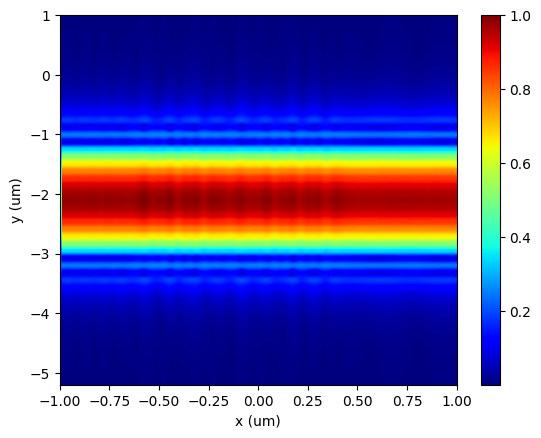

In [161]:
f = 2 
Ex = result['E'][:,:,0,f,0]
Ey = result['E'][:,:,0,f,1]
Ez = result['E'][:,:,0,f,2]
E_mag = np.sqrt(Ex**2+Ey**2+Ez**2)
E_mag /= np.max(np.abs(E_mag))
x = result['x']
y = result['y']
plt.imshow(np.abs(E_mag).T, extent = [np.min(y)*1e6, np.max(y)*1e6, np.min(x)*1e6, np.max(y)*1e6], aspect = 'auto', origin = 'lower', cmap = 'jet')
plt.xlabel('x (um)')
plt.ylabel('y (um)')
plt.colorbar()

### 1D Visualization

Now, let's check a 1D profile of the field decay. Since, the decayed field can be approximated by the eqn, 

$y(x) = exp(-\beta x)$

where, $\beta$ is the decay constant. 

An exponential curve is fitted and compared to the original data.

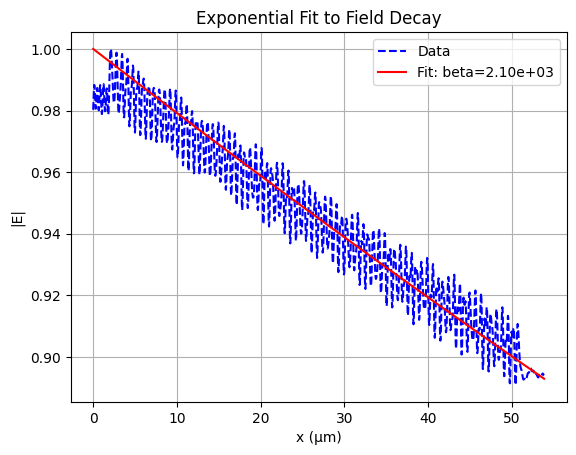

In [11]:
from scipy.optimize import curve_fit

# 1D profile along x at the center of y
center_y = E_mag.shape[1] // 2
x_vals = x.flatten()
x_vals = x_vals[1:]
x_vals = x_vals + np.abs(x_vals[0]) #xshift
y_ori = np.abs(E_mag[:, center_y])[1:]

# Define exponential decay function
def exp_decay(x, beta):
    return np.exp(-beta * x)

# Fit the data
popt, pcov = curve_fit(exp_decay, x_vals, y_ori)
y_fit = exp_decay(x_vals, popt[0])

# # Plot
plt.plot(x_vals * 1e6, y_ori, 'b--', label='Data')
plt.plot(x_vals * 1e6, y_fit, 'r-', label=f'Fit: beta={popt[0]:.2e}')
plt.title('Exponential Fit to Field Decay')
plt.xlabel('x (μm)')
plt.ylabel('|E|')
plt.legend()
plt.grid()
plt.show()

What happens if the propagating length is extended to extremly long length? Maybe to 1 mm ? Simulating such a long length is computationally time consuming, so an approximation is made by extrpolating the fitted data.

We can see that at long distance, the field decays to almost zero around 1 mm. Since my mesh accuracy is low, an exact data might not be replicated as in the paper. 

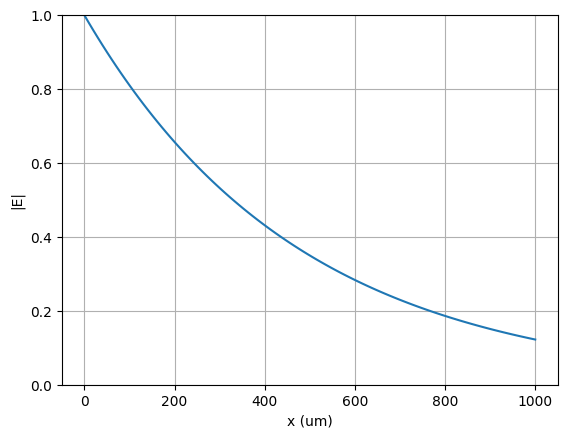

In [12]:
from scipy import interpolate
def extrapolate(x, y):
    return interpolate.interp1d(x, y, fill_value='extrapolate')

x_e = np.linspace(0, 1000e-6, 100)
y_e = exp_decay(x_e, popt[0])
plt.plot(x_e*1e6, y_e)
plt.ylim([0,1])
plt.xlabel('x (um)')
plt.ylabel('|E|')
plt.grid()

Now coming to our another part of the analysis: far field radiation pattern. 

Lumerical plots the farfield in cartesian coordinates by default. But with **farfield spherical()**, one can interpolate the results to polar coordinates. 

In [423]:
def farfield(sim):
    m  = 'monitor_1'
    res = 200
    f = np.arange(1, 6,1)
    E2 = sim.farfield3d(m,f,res,res)
    ux = sim.farfieldux(m,f,res,res)
    uy = sim.farfielduy(m,f,res,res)
    
    phi = sim.linspace(0,360,res)
    theta = sim.linspace(0,90,res)
    T = sim.meshgridx(theta, phi)
    P = sim.meshgridy(theta, phi)
    E2_ang = []
    
    for idx in f:
        E2_angle = sim.farfieldspherical(E2[:,:,idx-1],ux[:,idx-1],uy[:,idx-1],T,P)
        E2_ang.append(np.reshape(E2_angle, [len(theta), len(phi)]))
            
    result = [[ux,uy, E2], [T, P, np.array(E2_ang)]]
    return result



The last index of **E2** represents the frequency component that we saw in previous field decay. Now let's sweep our frequency points(wavelength values).

(200, 200, 5)


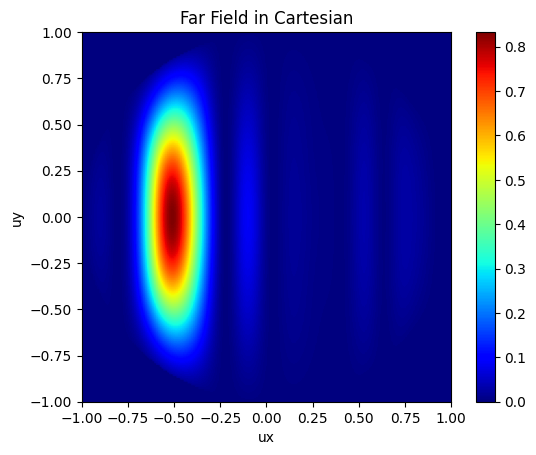

In [415]:
ff = farfield(fdtd)
c = ff[0]
p = ff[1]

ux, uy, E2 = c
T,P,E2_ang = p

print(E2.shape)

E2 /= np.max(E2) #norm

plt.imshow(E2[:,:,0].T, extent = [np.min(ux), np.max(ux), np.min(uy), np.max(uy)], origin = 'lower', cmap = 'jet')
plt.xlabel('ux')
plt.ylabel('uy')
plt.title('Far Field in Cartesian')
plt.colorbar()

In Polar Coordinates

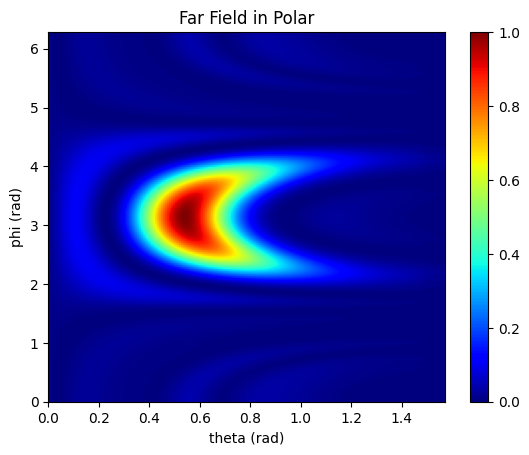

In [425]:
idx = 0
plt.imshow(E2_ang[idx,:,:]/np.max(E2_ang[idx,:,:]), extent = [np.min(T[:,0])*np.pi/180, np.max(T[:,0])*np.pi/180, np.min(P[0,:])*np.pi/180, np.max(P[0,:])*np.pi/180],aspect = 'auto', origin = 'lower',cmap ='jet' )
plt.xlabel('theta (rad)')
plt.ylabel('phi (rad)')
plt.title('Far Field in Polar')
plt.colorbar()

### Wavelength dependence on far field radaition

You see that with changing wavelength, the field shifts in direction as well as peak intensity. 

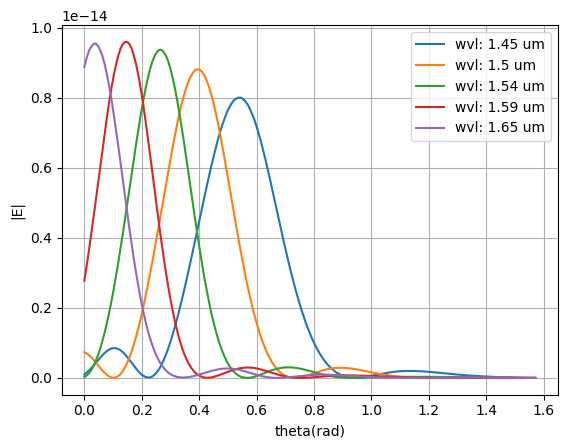

In [422]:
for itr in range(E2_ang.shape[0]):
    idx = np.unravel_index(np.argmax(E2_ang[itr,:,:]), E2_ang[itr,:,:].shape)
    plt.plot(T[:,0]*np.pi/180, E2_ang[itr, idx[0],:], label=f"wvl: {np.round(result['lambda'][4-itr][0]/1e-6, 2)} um")  #wvl and frequency points are inversely related
    plt.xlabel('theta(rad)')
    plt.ylabel('|E|')
    plt.title('')

plt.legend()
plt.grid()


## Array Factor

As we have now studied the far field radiation of a single antenna, we explore the influence of array of antenna on beam shiftng. 

$E_1(r, \theta) = AF * E_{0}(r,\theta)$ 

where, $E_0$ is a single element radiation field, AF is the array factor and $E_1$ is the final radiation field. 

$AF = \sum_{m=1}^{m=N_{arr}} w_m exp(-i*m*k*d*sin(\phi)*cos(\theta)+\psi)$

where, $w_m$ is the amplitude of the array factor, $N_{arr}$ is the total number of antenna arrays, k is the wavevector, d is the distance between the antennas, $\theta$ is the steering angles (either azimthual or polar angle), $\psi$ is the phase difference between the antennas. Here, we take the case of a linear phase array so the phase difference between the antennas is the same. The amplitude could be either unit value or weighted factor. 

The greater the $N_{arr}$ is, the narrower the beamwidth is. 

The distance between antennas should be less than half of the wavelength. 

In this simulation, unit amplitudes are taken for simplicity. 

You could play around with $N_{arr}$, phase values, d to see how it affects the beam steering. 

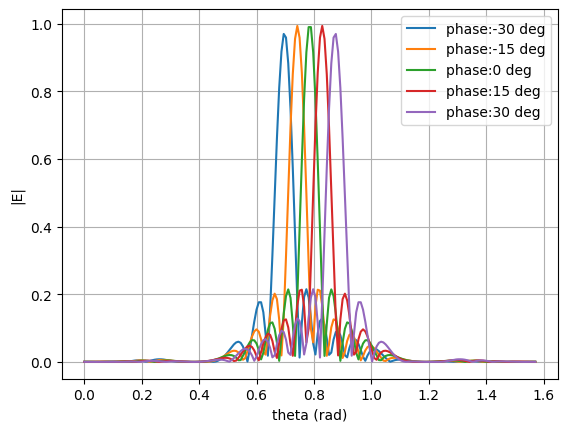

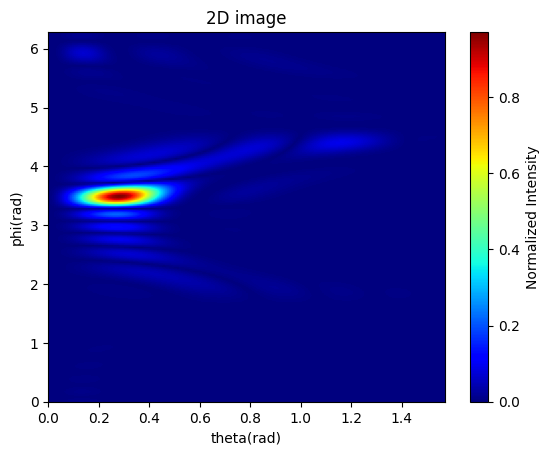

In [446]:
wvl = 1.55e-6  #although the corresponding wvl of the chosen electric field is 1.54 um, due to discrete points, we assume, there is not much differene 
k = 2 * np.pi / wvl
N_arr = 20
res = 200
phi = np.linspace(0, 2*np.pi, res)  # Azimuth angles
theta = np.linspace(0, np.pi/2, res)  # Azimuth angles
# d = 0.2*wvl
# Array Factor function
def array_factor(w, d, phases):
    THETA, PHI = np.meshgrid(theta, phi)  # Make 2D angular grid
    AF = np.zeros_like(PHI, dtype=complex)
    for m in range(1, N_arr + 1):
        AF += w[m-1] * np.exp(1j * ((m - 1) * (k * d * np.sin(PHI) * np.cos(THETA)) + phases[m-1]))
    return np.abs(AF)/np.max(np.abs(AF))  # Normalize

w = np.ones(N_arr)  # Uniform weights for the array element
d = 0.25 * wvl
# Linear phase progression: steer the beam
def finalE(p):
    plt.figure(1)
    E = E2_ang[2,:,:].copy()
    E /= np.max(E)
    for i in range(-p, p+1, p//2):
        p0 = np.deg2rad(i)
        phases = np.arange(N_arr) * p0
        AF = array_factor(w, d, phases)
        E_f = E*AF
        idx = np.unravel_index(np.argmax(E_f), E_f.shape)
        plt.plot(theta, E_f[:,idx[1]], label = f'phase:{i} deg')
    plt.xlabel('theta (rad)')
    plt.ylabel('|E|')
    plt.legend()
    plt.grid()

    #2D image
    plt.figure(2)
    plt.imshow(E_f,extent = [np.min(theta), np.max(theta), np.min(phi), np.max(phi)], aspect='auto', origin='lower', cmap = 'jet')
    plt.xlabel('theta(rad)')
    plt.ylabel('phi(rad)')
    plt.title('2D image')
    plt.colorbar(label='Normalized Intensity')

finalE(30)

### Animation of the beam steering 

Change the phase value and observe the beam steering. 

In [ ]:
import plotly.graph_objects as go

# Constants
wvl = 1.55e-6
k = 2 * np.pi / wvl
N_arr = 10
phi = np.linspace(0, 2*np.pi, 200)
theta = np.linspace(0, np.pi/2, 200)
THETA, PHI = np.meshgrid(theta, phi)

# Weight (uniform)
w = np.ones(N_arr)

# Array Factor function
def array_factor(w, d, phases):
    AF = np.zeros_like(PHI, dtype=complex)
    for m in range(N_arr):
        AF += w[m] * np.exp(1j * (m * k * d * np.cos(THETA) * np.sin(PHI) + phases[m]))
    return np.abs(AF) / np.max(np.abs(AF))

# Animation: Vary phase to steer beam
frames = []
d = 0.25 * wvl
steering_angles = np.arange(-20, 20, 5)
E = E2_ang[2,:,:].copy()
E /= np.max(E)

for angle in steering_angles:
    p0 = np.deg2rad(angle)
    phases = np.arange(N_arr) * p0
    AF = array_factor(w, d, phases)
    R = E*AF

    X = R * np.sin(THETA) * np.cos(PHI)
    Y = R * np.sin(THETA) * np.sin(PHI)
    Z = R * np.cos(THETA)

    surface = go.Surface(x=X, y=Y, z=Z, surfacecolor=R, colorscale='jet', showscale=False)
    frames.append(go.Frame(data=[surface], name=f'{angle:.1f}°'))

# Initial frame
initial_AF = array_factor(w, d, np.arange(N_arr) * np.deg2rad(steering_angles[0]))
R0 = E*initial_AF
X0 = R0 * np.sin(THETA) * np.cos(PHI)
Y0 = R0 * np.sin(THETA) * np.sin(PHI)
Z0 = R0 * np.cos(THETA)

# Create figure
fig = go.Figure(
    data=[go.Surface(x=X0, y=Y0, z=Z0, surfacecolor=R0, colorscale='jet', showscale=False)],
    frames=frames
)

fig.update_layout(
    title="Array Beam Steering Animation",
    scene=dict(
        xaxis=dict(range=[-1/2, 1/2], title='X'),
        yaxis=dict(range=[-1/2, 1/2], title='Y'),
        zaxis=dict(range=[-1/2, 1], title='Z'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1)
    ),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(label='Play',
                      method='animate',
                      args=[None, dict(frame=dict(duration=100, redraw=True), fromcurrent=True)])]
    )]
)
fig.show()
